In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from tqdm.notebook import tqdm
import time
import math
import os
import zipfile
#---
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
#---
from sklearn.ensemble import RandomForestClassifier
#---
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
ZIP_PATH = 'transaction_dataset.csv.zip'
CSV_PATH = 'data/transaction_dataset.csv'

if not os.path.exists(CSV_PATH):
    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('data/')

print("Loading data into memory...")
df = pd.read_csv(CSV_PATH)

df.drop(columns=['Index', 'Address'], inplace=True)

Loading data into memory...


In [3]:
def df_details(dataset=None):
    column = []
    dtype = []
    unique = []
    count = []
    missing = []
    missing_percent = []
    mean_ = []
    std_ = []
    min_ = []
    max_ = []
    skew_ = []
    for col in df.columns:
        column.append(col)
        dtype.append(df[col].dtype)
        unique.append(len(df[col].unique()))
        count.append(len(df[col]))
        missing.append(df[col].isna().sum())
        missing_percent.append(round(df[col].isna().sum()*100/len(df[col]), 2))
        if df[col].dtype =='int' or df[col].dtype =='float':
            mean_.append(df[col].mean())
            std_.append(df[col].std())
            min_.append(df[col].min())
            max_.append(df[col].max())
            skew_.append(round(df[col].skew()))
        else:
            mean_.append(0)
            std_.append(0)
            min_.append(0)
            max_.append(0)
            skew_.append(0)

    data_info = pd.DataFrame({'Feature':column,'Dtype':dtype, 'Unique':unique,'Count':count,'Missing_Value':missing,'Missing_Value_Percent':missing_percent,'MEAN':mean_,'STD':std_,'MIN':min_,'MAX':max_,'SKEW':skew_})
    return data_info

df_details()            

,Feature,Dtype,Unique,Count,Missing_Value,Missing_Value_Percent,MEAN,STD,MIN,MAX,SKEW
0,Unnamed: 0,int64,9841,9841,0,0.00,4.920000e+03,2.840996e+03,0.00,9.840000e+03,0
1,FLAG,int64,2,9841,0,0.00,2.214206e-01,4.152241e-01,0.00,1.000000e+00,1
2,Avg min between sent tnx,float64,5013,9841,0,0.00,5.086879e+03,2.148655e+04,0.00,4.302877e+05,8
3,Avg min between received tnx,float64,6223,9841,0,0.00,8.004851e+03,2.308171e+04,0.00,4.821755e+05,7
4,Time Diff between first and last (Mins),float64,7810,9841,0,0.00,2.183333e+05,3.229379e+05,0.00,1.954861e+06,2
5,Sent tnx,int64,641,9841,0,0.00,1.159317e+02,7.572264e+02,0.00,1.000000e+04,10
6,Received Tnx,int64,727,9841,0,0.00,1.637009e+02,9.408366e+02,0.00,1.000000e+04,9
7,Number of Created Contracts,int64,20,9841,0,0.00,3.729702e+00,1.414456e+02,0.00,9.995000e+03,52
8,Unique Received From Addresses,int64,256,9841,0,0.00,3.036094e+01,2.986211e+02,0.00,9.999000e+03,18
9,Unique Sent To Addresses,int64,258,9841,0,0.00,2.584016e+01,2.638204e+02,0.00,9.287000e+03,18


In [4]:
df.columns = df.columns.str.replace(' ', '_')

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
print(df.columns)
print(df.shape)
print(df['FLAG'].value_counts())

Index(['Unnamed:_0', 'FLAG', 'Avg_min_between_sent_tnx',
       'Avg_min_between_received_tnx',
       'Time_Diff_between_first_and_last_(Mins)', 'Sent_tnx', 'Received_Tnx',
       'Number_of_Created_Contracts', 'Unique_Received_From_Addresses',
       'Unique_Sent_To_Addresses', 'min_value_received', 'max_value_received_',
       'avg_val_received', 'min_val_sent', 'max_val_sent', 'avg_val_sent',
       'min_value_sent_to_contract', 'max_val_sent_to_contract',
       'avg_value_sent_to_contract',
       'total_transactions_(including_tnx_to_create_contract',
       'total_Ether_sent', 'total_ether_received',
       'total_ether_sent_contracts', 'total_ether_balance',
       '_Total_ERC20_tnxs', '_ERC20_total_Ether_received',
       '_ERC20_total_ether_sent', '_ERC20_total_Ether_sent_contract',
       '_ERC20_uniq_sent_addr', '_ERC20_uniq_rec_addr',
       '_ERC20_uniq_sent_addr.1', '_ERC20_uniq_rec_contract_addr',
       '_ERC20_avg_time_between_sent_tnx', '_ERC20_avg_time_between_rec

In [7]:
# Drop unnecessary column
if 'Unnamed:_0' in df.columns:
    df.drop(columns=['Unnamed:_0'], inplace=True)

# Handle missing values: fill with median for numerical columns
for col in df.columns:
    if df[col].isna().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())

print("Data shape after cleaning:", df.shape)
print("Missing values per column:")
print(df.isna().sum().sum())

Data shape after cleaning: (9841, 48)
Missing values per column:
3568


In [8]:
# Separate features and target
X = df.select_dtypes(include=[np.number]).drop(columns=['FLAG'])
y = df['FLAG']

# Feature selection using mutual information
mi_scores = mutual_info_classif(X, y)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Select top features (e.g., top 20)
top_features = mi_scores.head(20).index
X_selected = X[top_features]

# Further feature reduction
# 1. Remove zero variance features
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.0)
X_var = selector.fit_transform(X_selected)
selected_features_var = X_selected.columns[selector.get_support()]

# 2. Remove highly correlated features (correlation > 0.9)
corr_matrix = X_selected[selected_features_var].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
selected_features_corr = [col for col in selected_features_var if col not in to_drop]

# 3. Remove sparse features (more than 90% zeros)
sparse_threshold = 0.9
sparse_features = []
for col in selected_features_corr:
    zero_ratio = (X_selected[col] == 0).sum() / len(X_selected)
    if zero_ratio <= sparse_threshold:
        sparse_features.append(col)

X_final = X_selected[sparse_features]

print(f"Features after variance threshold: {len(selected_features_var)}")
print(f"Features after correlation removal: {len(selected_features_corr)}")
print(f"Final features after sparsity removal: {len(sparse_features)}")
print("Final features:", list(X_final.columns))

Features after variance threshold: 20
Features after correlation removal: 18
Final features after sparsity removal: 18
Final features: ['_Total_ERC20_tnxs', '_ERC20_uniq_rec_contract_addr', '_ERC20_uniq_rec_addr', 'Time_Diff_between_first_and_last_(Mins)', 'max_value_received_', 'total_ether_balance', 'avg_val_received', 'total_ether_received', '_ERC20_min_val_rec', '_ERC20_avg_val_rec', 'total_transactions_(including_tnx_to_create_contract', 'Received_Tnx', 'Unique_Received_From_Addresses', 'min_value_received', 'Avg_min_between_received_tnx', 'total_Ether_sent', 'Avg_min_between_sent_tnx', '_ERC20_max_val_rec']


In [9]:
# Balance the dataset using SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_final, y)

print("Original class distribution:")
print(y.value_counts())
print("Balanced class distribution:")
print(pd.Series(y_balanced).value_counts())

Original class distribution:
FLAG
0    7662
1    2179
Name: count, dtype: int64
Balanced class distribution:
FLAG
0    7662
1    7662
Name: count, dtype: int64


In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (12259, 18) (12259,)
Test shape: (3065, 18) (3065,)


In [11]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [12]:
# Train three models
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, objective='binary:logistic')
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

RandomForest trained.
SVM trained.
LogisticRegression trained.
XGBoost trained.


In [13]:
# Evaluate the models
from sklearn.model_selection import cross_val_score

results = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'CV Accuracy': cv_mean
    }
    
    print(f"\n{name} Results:")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Cross-Val Accuracy: {cv_mean:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# Compare models
print("\nModel Comparison:")
for name, metrics in results.items():
    print(f"{name}: Test Acc={metrics['Accuracy']:.4f}, CV Acc={metrics['CV Accuracy']:.4f}")

best_model = max(results, key=lambda x: results[x]['Accuracy'])
print(f"\nBest model based on test accuracy: {best_model}")

# Feature importance for RandomForest
if 'RandomForest' in trained_models:
    feature_importance = pd.Series(trained_models['RandomForest'].feature_importances_, index=X_final.columns).sort_values(ascending=False)
    print("\nTop 10 important features (RandomForest):")
    print(feature_importance.head(10))


RandomForest Results:
Test Accuracy: 0.9860
Precision: 0.9844
Recall: 0.9876
F1 Score: 0.9860
Cross-Val Accuracy: 0.9852
Confusion Matrix:
[[1509   24]
 [  19 1513]]

SVM Results:
Test Accuracy: 0.8007
Precision: 0.7507
Recall: 0.9001
F1 Score: 0.8186
Cross-Val Accuracy: 0.7914
Confusion Matrix:
[[1075  458]
 [ 153 1379]]

LogisticRegression Results:
Test Accuracy: 0.7086
Precision: 0.6552
Recall: 0.8805
F1 Score: 0.7513
Cross-Val Accuracy: 0.7076
Confusion Matrix:
[[ 823  710]
 [ 183 1349]]


KeyboardInterrupt: 

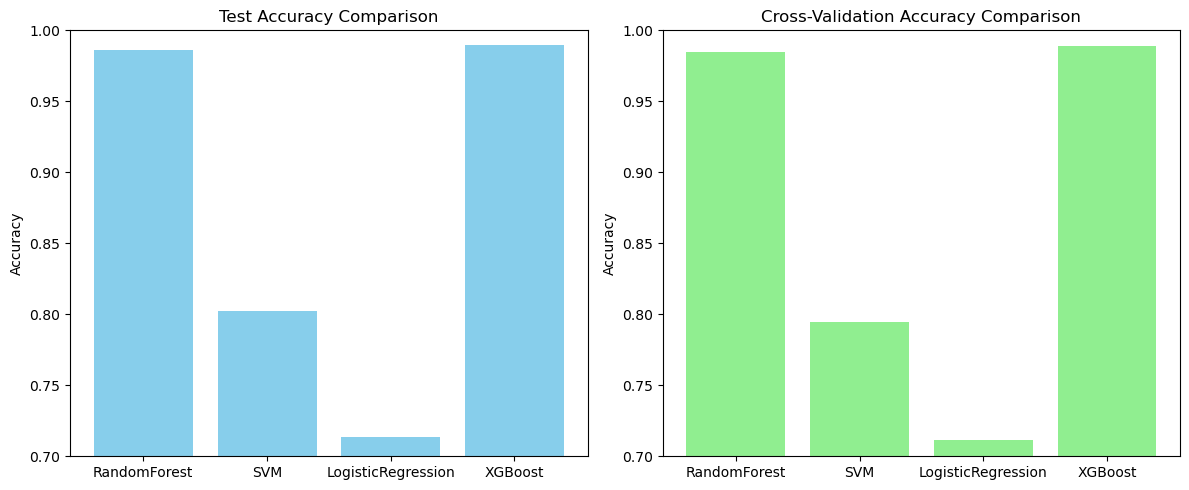

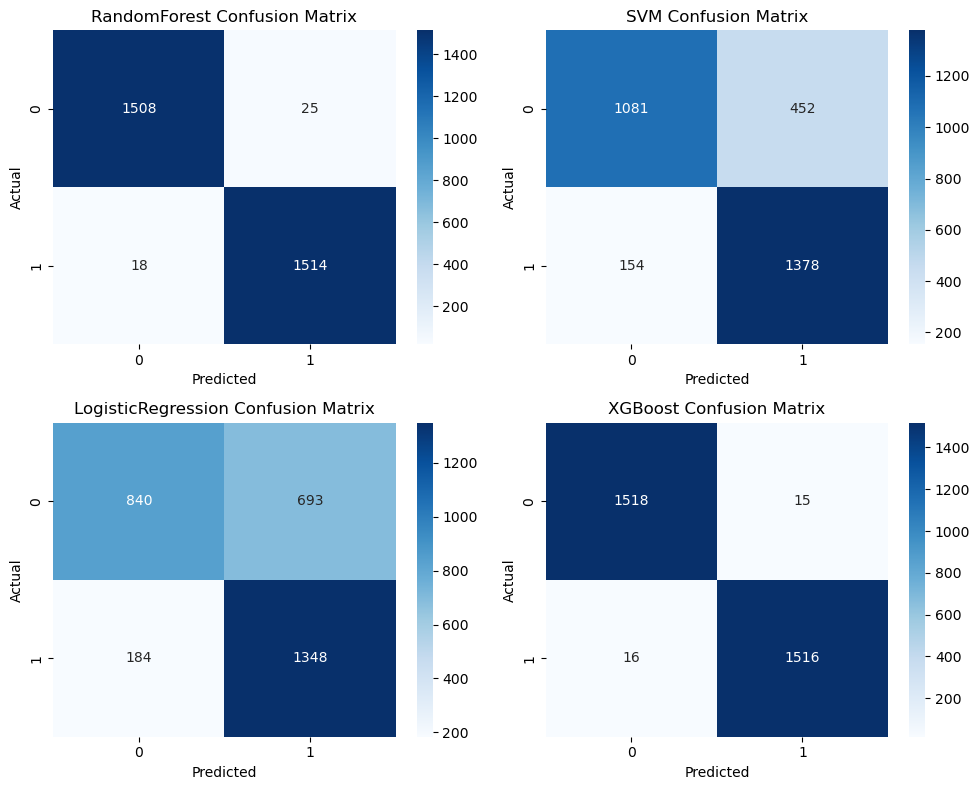

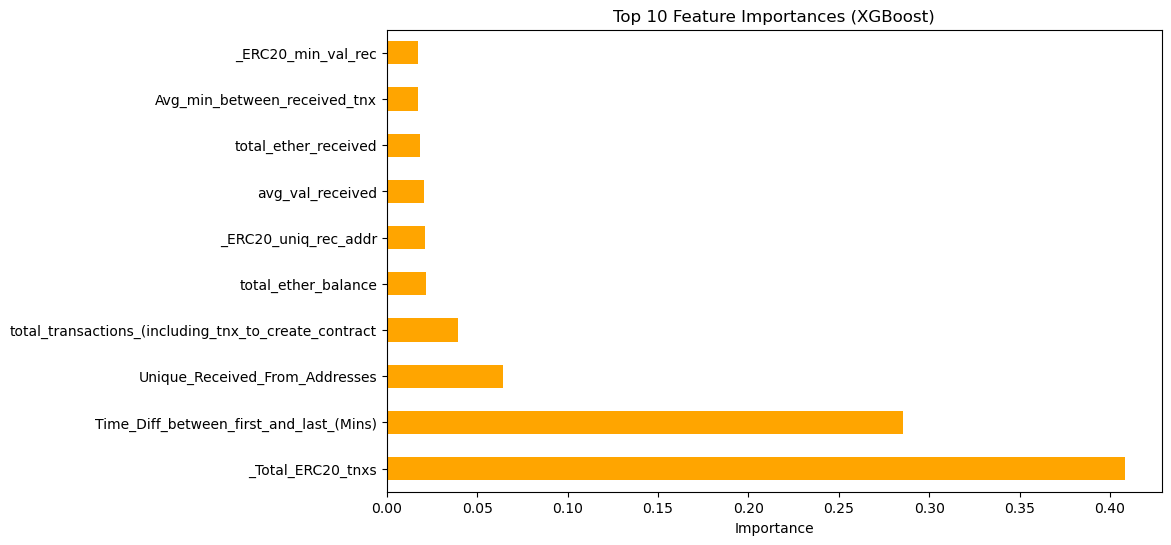

In [ ]:
# Plot model comparison
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot for accuracies
model_names = list(results.keys())
test_accs = [results[name]['Accuracy'] for name in model_names]
cv_accs = [results[name]['CV Accuracy'] for name in model_names]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(model_names, test_accs, color='skyblue')
ax[0].set_title('Test Accuracy Comparison')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(0.7, 1.0)

ax[1].bar(model_names, cv_accs, color='lightgreen')
ax[1].set_title('Cross-Validation Accuracy Comparison')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0.7, 1.0)

plt.tight_layout()
plt.show()

# Confusion matrices for each model
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, name in enumerate(model_names):
    y_pred = trained_models[name].predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature importance for XGBoost
if 'XGBoost' in trained_models:
    xgb_model = trained_models['XGBoost']
    feature_importance_xgb = pd.Series(xgb_model.feature_importances_, index=X_final.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    feature_importance_xgb.head(10).plot(kind='barh', color='orange')
    plt.title('Top 10 Feature Importances (XGBoost)')
    plt.xlabel('Importance')
    plt.show()

In [ ]:
# Plot learning curves to check for overfitting
from sklearn.model_selection import learning_curve

# Use a smaller subset and parallel jobs to speed up learning curves
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Create a smaller sample if the training set is large
X_lc = X_train_scaled
y_lc = y_train
if getattr(X_lc, 'shape', (0,))[0] > 20000:
    sample_frac = 0.5
    n = int(X_lc.shape[0] * sample_frac)
    X_lc = X_lc[:n]
    y_lc = y_lc[:n]

for i, name in enumerate(model_names):
    # Skip SVM with default RBF kernel (can be extremely slow on large data)
    if name == 'SVM':
        axes[i].text(0.5, 0.5, 'Skipped (slow)', horizontalalignment='center', verticalalignment='center')
        axes[i].set_title(f'{name} Learning Curve (skipped)')
        continue

    model = models[name]  # use the unfitted estimator
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_lc, y_lc, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42, n_jobs=-1, verbose=1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    axes[i].plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    axes[i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    axes[i].plot(train_sizes, val_mean, 'o-', color='red', label='Validation score')
    axes[i].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')

    axes[i].set_title(f'{name} Learning Curve')
    axes[i].set_xlabel('Training Size')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()